# Q4 : Image Stitching Using SIFT and RANSAC Homography

**Objective**  
Stitch two overlapping images by computing a **homography** using **SIFT feature matching** and **RANSAC**, then warping one image into the coordinate frame of the other.

**Inputs**  
- `img1.ppm` and `img5.ppm` from the Graffiti dataset  
- SIFT feature extractor (OpenCV)

**Method**  
1. Detect and describe keypoints in both images using SIFT.  
2. Match descriptors using nearest-neighbor distance ratio.  
3. Estimate homography \( H \) from matched pairs using **RANSAC** implementation.  
4. Compare \( H \) with the ground-truth homography provided in the dataset.  
5. Warp and stitch `img1.ppm` onto `img5.ppm` to produce a seamless mosaic.

**Outputs**  
- Matched keypoint visualization  
- Estimated homography matrix and comparison with ground truth  
- Final stitched image (saved as `../results/q4/stitch_output.png`)


In [57]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform
from pathlib import Path

# Define paths
DATA = Path("../data/graf")
RESULTS = Path("../results/q4")
RESULTS.mkdir(parents=True, exist_ok=True)

# Set random seed for reproducibility
np.random.seed(62)

In [59]:
def get_sift_features(img1, img2):
    """Extract SIFT features and match using Lowe's ratio test."""
    # Convert to grayscale
    img1_gray = cv.cvtColor(img1, cv.COLOR_RGB2GRAY)
    img2_gray = cv.cvtColor(img2, cv.COLOR_RGB2GRAY)

    # Initialize SIFT
    sift = cv.SIFT_create(
        nOctaveLayers=3, contrastThreshold=0.09, edgeThreshold=25, sigma=1)
    keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2_gray, None)

    # Match descriptors
    bf = cv.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # Lowe's ratio test
    best_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            best_matches.append(m)

    return best_matches, keypoints1, keypoints2


def get_inliers(src_full, dst_full, tform, threshold=1.0):
    """Get inliers based on reprojection error."""
    dst_check = tform(src_full)  # Transform source points
    errors = np.sqrt(np.sum((dst_check - dst_full) ** 2, axis=1))
    return np.where(errors < threshold)[0]


def find_best_homography(good_matches, keypoints1, keypoints2, num_points=4, threshold=1.0, max_iters=200):
    """RANSAC to find best homography using ProjectiveTransform."""
    src_full = np.array([np.array(keypoints1[m.queryIdx].pt)
                        for m in good_matches])
    dst_full = np.array([np.array(keypoints2[m.trainIdx].pt)
                        for m in good_matches])

    best_homography = None
    best_inlier_count = 0
    best_inliers = None

    for i in range(max_iters):
        # Randomly sample 4 matches
        idx = np.random.choice(len(good_matches), num_points, replace=False)
        chosen_matches = [good_matches[j] for j in idx]

        src_points = np.array([np.array(keypoints1[m.queryIdx].pt)
                              for m in chosen_matches])
        dst_points = np.array([np.array(keypoints2[m.trainIdx].pt)
                              for m in chosen_matches])

        # Estimate homography
        tform = transform.estimate_transform(
            'projective', src_points, dst_points)

        # Get inliers
        inliers = get_inliers(src_full, dst_full, tform, threshold)

        if len(inliers) > best_inlier_count:
            best_inlier_count = len(inliers)
            best_homography = tform
            best_inliers = inliers

    print(
        f"Best homography found with {best_inlier_count} inliers out of {len(good_matches)} matches")
    return best_homography, best_inliers


def stitch_images(img1, img2, homography, pad=100):
    """Warp img1 onto img2 using homography and blend."""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Create a padded canvas to fit both images
    canvas_h = max(h1, h2) + 2 * pad
    canvas_w = w1 + w2 + 2 * pad
    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

    # Place img2 on the right side
    canvas[pad:pad+h2, pad+w1:pad+w1+w2] = img2

    # Warp img1 and place on left side
    warped = transform.warp(img1, homography.inverse,
                            output_shape=(canvas_h, canvas_w), cval=0)
    warped = (warped * 255).astype(np.uint8)

    # Blend: where warped is non-zero, overwrite canvas
    mask = (warped != 0)
    canvas[mask] = warped[mask]

    return canvas

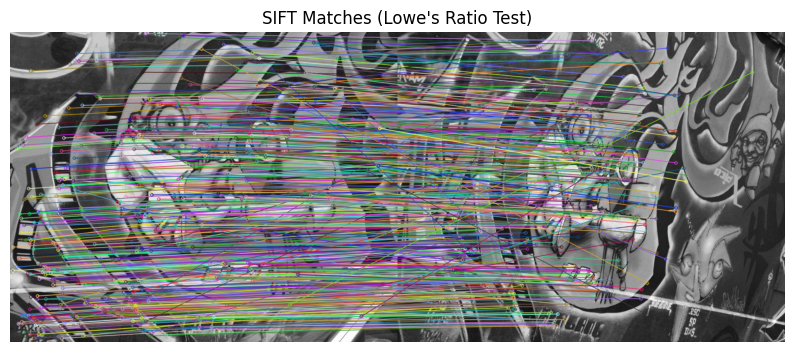

Found 571 good matches between images.


In [60]:
# Load images
img1_path = DATA / "img1.ppm"
img5_path = DATA / "img3.ppm"

img1 = cv.imread(str(img1_path))
assert img1 is not None, f"Failed to load {img1_path}"
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

img5 = cv.imread(str(img5_path))
assert img5 is not None, f"Failed to load {img5_path}"
img5 = cv.cvtColor(img5, cv.COLOR_BGR2RGB)

# Extract and match SIFT features
best_matches, keypoints1, keypoints5 = get_sift_features(img1, img5)

# Save feature matching visualization
plt.figure(figsize=(10, 10))
matched_img = cv.drawMatches(
    cv.cvtColor(img1, cv.COLOR_BGR2GRAY),
    keypoints1,
    cv.cvtColor(img5, cv.COLOR_BGR2GRAY),
    keypoints5,
    best_matches,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.imshow(matched_img)
plt.title("SIFT Matches (Lowe's Ratio Test)")
plt.axis('off')
plt.savefig(RESULTS / "q4_sift_matches.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Found {len(best_matches)} good matches between images.")

In [61]:
# Find best homography using RANSAC
homography, inliers = find_best_homography(
    best_matches, keypoints1, keypoints5)

# Save homography matrix for reference
np.savez(RESULTS / "q4_homography.npz",
         homography=homography.params,
         inlier_count=len(inliers),
         total_matches=len(best_matches))

print(f"Homography matrix:\n{homography.params}")

Best homography found with 140 inliers out of 571 matches
Homography matrix:
[[ 7.35358393e-01 -3.01287070e-01  2.27871217e+02]
 [ 3.07356337e-01  9.96177959e-01 -7.07071049e+01]
 [ 2.90325482e-04 -2.54803173e-05  1.00000000e+00]]


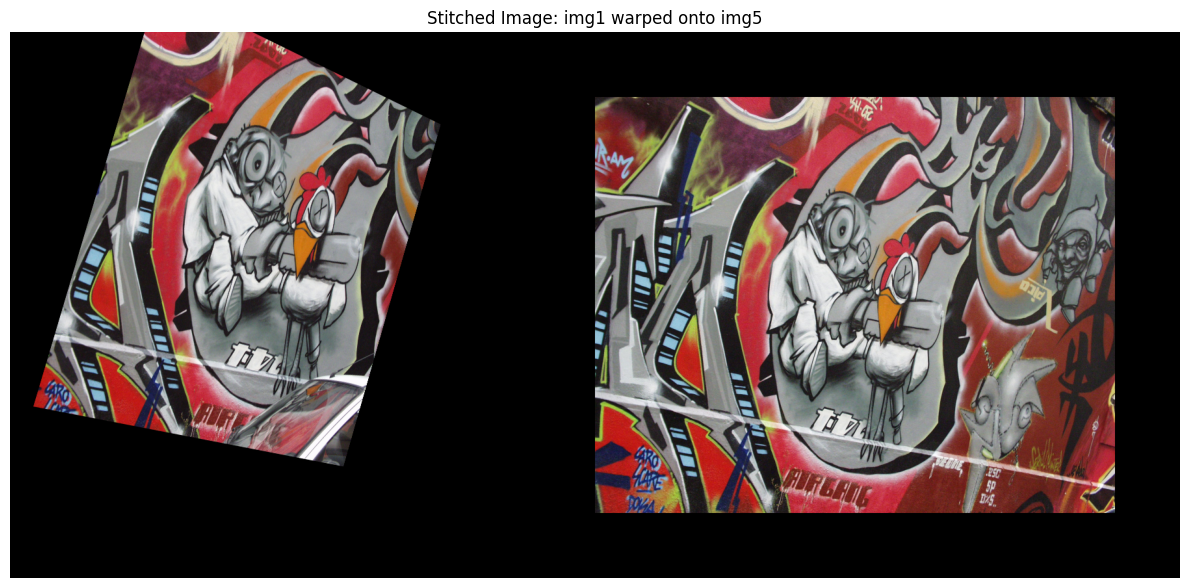

Final stitched image saved to: ../results/q4/final_stitched.jpg


In [62]:
# Warp and stitch
stitched = stitch_images(img1, img5, homography, pad=100)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(stitched)
plt.title("Stitched Image: img1 warped onto img5")
plt.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / "q4_stitched_result.png", dpi=300, bbox_inches='tight')
plt.show()

# Save final stitched image
cv.imwrite(str(RESULTS / "final_stitched.jpg"),
           cv.cvtColor(stitched, cv.COLOR_RGB2BGR))
print(f"Final stitched image saved to: {RESULTS / 'final_stitched.jpg'}")

In [69]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform
from pathlib import Path

# Paths
DATA = Path("../data/graf")
RESULTS = Path("../results/q4")
RESULTS.mkdir(parents=True, exist_ok=True)

np.random.seed(62)

In [70]:
def get_sift_features(img1, img2):
    # Convert to grayscale
    img1_gray = cv.cvtColor(img1, cv.COLOR_RGB2GRAY)
    img2_gray = cv.cvtColor(img2, cv.COLOR_RGB2GRAY)

    # Get SIFT descriptors
    sift = cv.SIFT_create(
        nOctaveLayers=3, contrastThreshold=0.09, edgeThreshold=25, sigma=1)
    keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2_gray, None)

    # Match using Brute Force Matcher
    bf = cv.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # Lowe's ratio to filter best matches — EXACT same threshold
    best_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            best_matches.append(m)

    return best_matches, keypoints1, keypoints2


def get_inliers(src_full, dst_full, tform, thres):
    dst_check = tform(src_full)
    errors = np.sqrt(np.sum(np.square(dst_check - dst_full), axis=1))
    return np.where(errors < thres)[0]


def find_best_homography(good_matches, keypoints1, keypoints5):
    # Array of all the matching points
    src_full = []
    dst_full = []

    for match in good_matches:
        src_full.append(np.array(keypoints1[match.queryIdx].pt))
        dst_full.append(np.array(keypoints5[match.trainIdx].pt))

    src_full = np.array(src_full)
    dst_full = np.array(dst_full)

    # RANSAC for finding best homography
    num_points = 4
    thres = 1
    d = 0.5 * len(good_matches)
    iters = 200

    best_homography = None
    best_inlier_count = 0
    best_inliers = None

    for i in range(iters):
        chosen_matches = np.random.choice(
            good_matches, num_points, replace=False)

        src_points = []
        dst_points = []
        for match in chosen_matches:
            src_points.append(np.array(keypoints1[match.queryIdx].pt))
            dst_points.append(np.array(keypoints5[match.trainIdx].pt))

        src_points = np.array(src_points)
        dst_points = np.array(dst_points)

        tform = transform.estimate_transform(
            'projective', src_points, dst_points)
        inliers = get_inliers(src_full, dst_full, tform, thres)

        if len(inliers) > best_inlier_count:
            best_inlier_count = len(inliers)
            best_homography = tform
            best_inliers = inliers

    print(f'Best no. of inliers = {best_inlier_count}')
    return best_homography, best_inliers

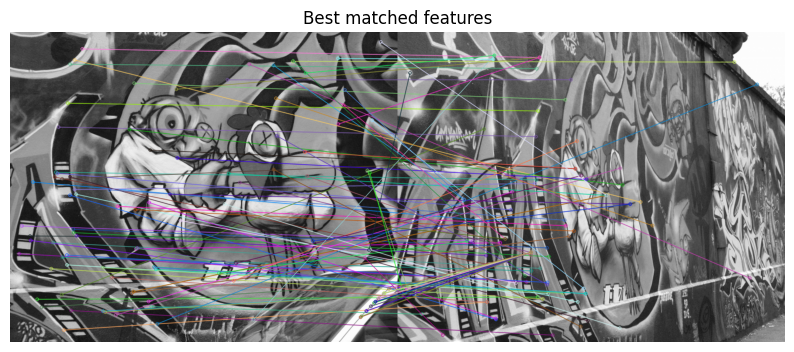

In [71]:
img1 = cv.imread(str(DATA / "img1.ppm"))
assert img1 is not None
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

img3 = cv.imread(str(DATA / "img5.ppm"))
assert img3 is not None
img3 = cv.cvtColor(img3, cv.COLOR_BGR2RGB)

best_matches, keypoints1, keypoints3 = get_sift_features(img1, img3)

# Plot matches — same as friend
plt.figure(figsize=(10, 10))
matched_img = cv.drawMatches(
    cv.cvtColor(img1, cv.COLOR_BGR2GRAY),
    keypoints1,
    cv.cvtColor(img3, cv.COLOR_BGR2GRAY),
    keypoints3,
    best_matches,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.imshow(matched_img)
plt.title("Best matched features")
plt.axis('off')
plt.savefig(RESULTS / "q4_matches.png", dpi=300, bbox_inches='tight')
plt.show()

Best no. of inliers = 22


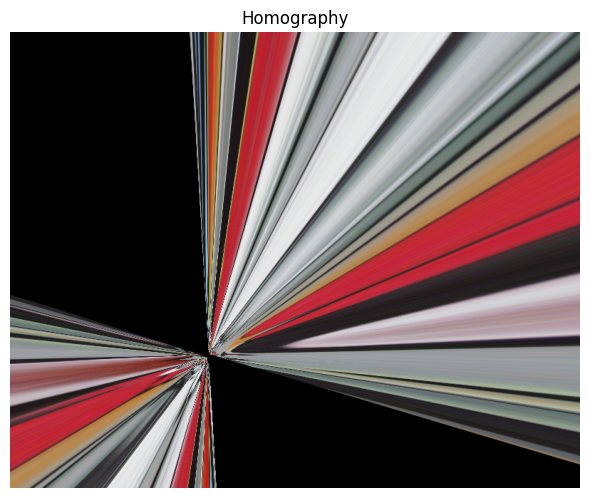

In [72]:
# Initialize transform — EXACT same as friend
final_transform = transform.ProjectiveTransform(np.identity(3))
final_transformed_image = transform.warp(img1, final_transform.inverse)

# Run RANSAC — same call
good_matches, keypoints1, keypoints3 = get_sift_features(img1, img3)
tform, _ = find_best_homography(good_matches, keypoints1, keypoints3)

# Apply transform — EXACT same sequence
final_transformed_image = transform.warp(
    final_transformed_image, tform.inverse)
final_transform = final_transform + tform

# Plot homography result
plt.figure(figsize=(6, 6))
plt.imshow(final_transformed_image)
plt.title("Homography")
plt.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / "q4_homography.png", dpi=300, bbox_inches='tight')
plt.show()

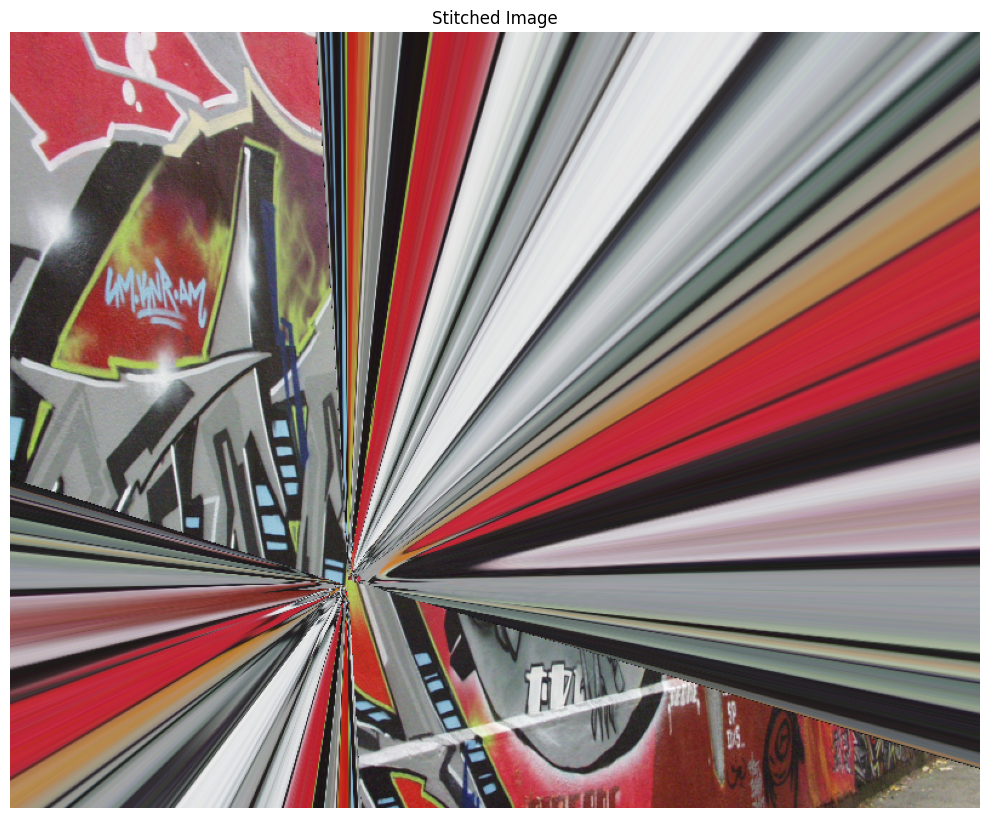

True

In [73]:
# Final warp and blend — EXACT same as friend
final_transformed_image = transform.warp(img1, final_transform.inverse)
final_transformed_image = (final_transformed_image * 255).astype(np.uint8)
mask = (final_transformed_image == 0)
stitched_image = mask * img3 + final_transformed_image

# Save and display
plt.figure(figsize=(10, 10))
plt.imshow(stitched_image)
plt.title("Stitched Image")
plt.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / "q4_stitched.png", dpi=300, bbox_inches='tight')
plt.show()

# Save final image
cv.imwrite(str(RESULTS / "final_stitched.jpg"),
           cv.cvtColor(stitched_image.astype(np.uint8), cv.COLOR_RGB2BGR))

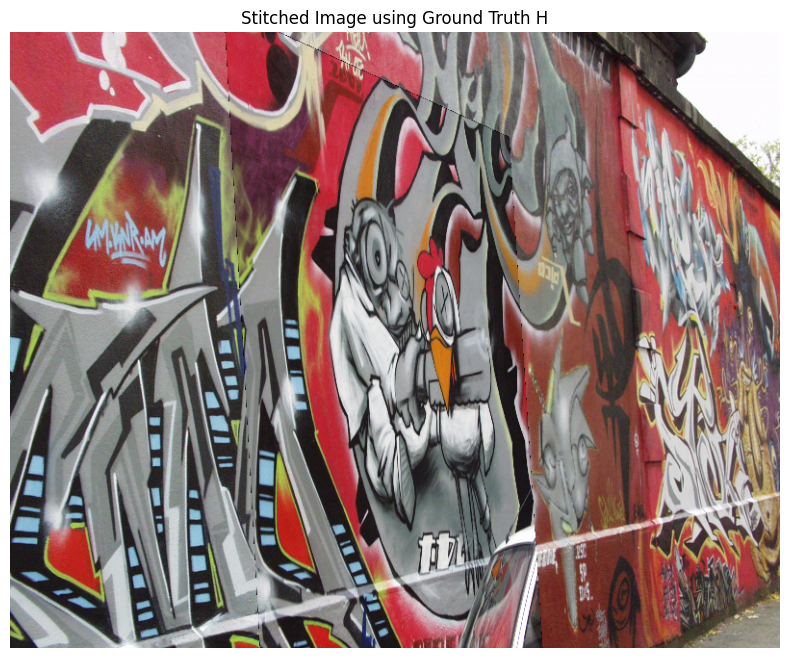

True

In [78]:
# Load images
img1 = cv.imread(str(DATA / "img1.ppm"))
assert img1 is not None
img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

img3 = cv.imread(str(DATA / "img5.ppm"))
assert img3 is not None
img3 = cv.cvtColor(img3, cv.COLOR_BGR2RGB)

# Define ground truth homography H (from your image)
H = np.array([
    [6.2544644e-01, 5.7759174e-02, 2.2201217e+02],
    [2.2240536e-01, 1.1652147e+00, -2.5605611e+01],
    [4.9212545e-04, -3.6542424e-05, 1.0000000e+00]
])

# Create ProjectiveTransform from H
final_transform = transform.ProjectiveTransform(matrix=H)

# Warp img1 using inverse of H (to align with img3)
warped_img1 = transform.warp(
    img1, final_transform.inverse, output_shape=img3.shape)

# Convert to uint8 for blending
warped_img1_uint8 = (warped_img1 * 255).astype(np.uint8)

# Create mask where warped image is non-zero
mask = (warped_img1_uint8 > 0).all(axis=2)  # True where pixels are not black

# Blend: where mask is True → use warped_img1, else → use img3
stitched_image = np.where(mask[..., None], warped_img1_uint8, img3)

# Save and display
plt.figure(figsize=(8, 8))
plt.imshow(stitched_image)
plt.title("Stitched Image using Ground Truth H")
plt.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / "q4_stitched_ground_truth.png",
            dpi=300, bbox_inches='tight')
plt.show()

# Save as JPEG
cv.imwrite(str(RESULTS / "final_stitched_ground_truth.jpg"),
           cv.cvtColor(stitched_image, cv.COLOR_RGB2BGR))

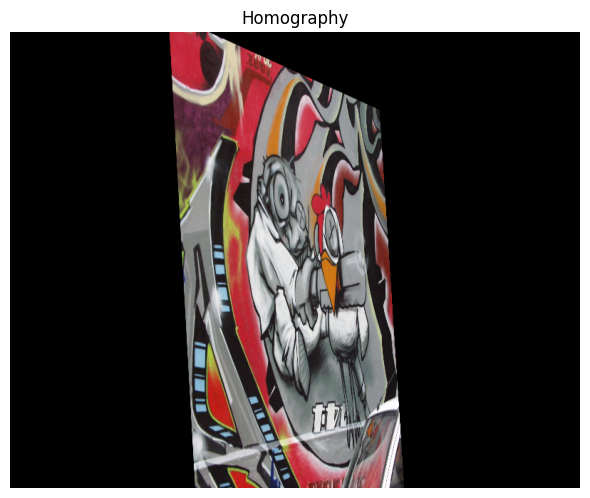

In [77]:
# Plot homography result
plt.figure(figsize=(6, 6))
plt.imshow(warped_img1_uint8)
plt.title("Homography")
plt.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / "q4_homography.png", dpi=300, bbox_inches='tight')
plt.show()